## 0. Imports/Constants

In [1]:
import uproot
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys,os
import argparse
from tqdm import tqdm
import glob

#CAFPYANA working directory
CAFPYANA_WD = '/exp/sbnd/app/users/brindenc/develop/cafpyana'
os.environ['CAFPYANA_WD'] = CAFPYANA_WD

cafpyana_wd = os.environ.get('CAFPYANA_WD')
if cafpyana_wd and cafpyana_wd not in sys.path:
    sys.path.insert(0, cafpyana_wd)
    sys.path.insert(0, cafpyana_wd + '/pyanalib')

#My imports
SBNDANA_DIR = '/exp/sbnd/app/users/brindenc/develop/cafpyana/analysis_village/numuincl/sbnd'
sys.path.insert(0,SBNDANA_DIR)
sys.path.insert(0,f'{SBNDANA_DIR.replace("/numuincl/sbnd","/numuincl")}')
plt.style.use(f'{SBNDANA_DIR}/plotlibrary/numu2025.mplstyle')

from sbnd.cafclasses.slice import CAFSlice
from sbnd.cafclasses.pfp import PFP
from sbnd.cafclasses.nu import NU
from sbnd.constants import *
from sbnd.numu.numu_constants import *
from sbnd.detector.definitions import *
from sbnd.general import plotters
from naming import *
from sbnd.general.utils import read_hdf

%load_ext autoreload
%autoreload 2

In [2]:
# Fill these
checkpoint = 'checkpoint9_denttest2'
VERSION = 'v10'
NCPU = 16
SMALL = True
FILTER_PFP = False

PLOT_DIR = f'{DATA_DIR}/plots/{checkpoint}/dent_studies'

#MC Fnames
# Use syst file
MC_FNAMES = glob.glob(
  f'{DATA_DIR}/mc_syst/{VERSION}/*_nosyst*/*.df'
)

MC_DATADRIVEN_FNAMES = glob.glob(
  f'{DATA_DIR}/dent/datadriven_v4/{VERSION}/*_datadriven*/*.df'
)

# Use nominal file
# MC_FNAMES = glob.glob(
#   f'{DATA_DIR}/det_var/nominal/{VERSION}/*_nominal*/*.df'
# )
DATA_OFFBEAM_FNAMES = glob.glob(
  f'{DATA_DIR}/offbeam/{VERSION}/*data*/*.df'
)
# DATA_FNAMES = glob.glob(
#   f'{DATA_DIR}/data/{VERSION}/*dataonbeam*/*.df'
# )
DATA_FNAMES = glob.glob(
  f'{DATA_DIR}/data/{VERSION}/dataonbeam_dev.df'
)
DATA_REP_FNAMES = glob.glob(
  f'{DATA_DIR}/dent/dent_reprocess_data/{VERSION}/*dent_reprocess_data*/*.df'
)

MC_LOWE_FNAMES = glob.glob(
  f'{DATA_DIR}/mc_lowe/{VERSION}/*_mclowe_*/*.df'
)

LEN_MC_FNAMES = len(MC_FNAMES)
LEN_DATA_OFFBEAM_FNAMES = len(DATA_OFFBEAM_FNAMES)
LEN_DATA_FNAMES = len(DATA_FNAMES)
LEN_MC_LOWE_FNAMES = len(MC_LOWE_FNAMES)
LEN_MC_DATADRIVEN_FNAMES = len(MC_DATADRIVEN_FNAMES)
LEN_DATA_REP_FNAMES = len(DATA_REP_FNAMES)

if SMALL:
  MC_FNAMES = MC_FNAMES[:len(MC_FNAMES)//10]
  DATA_OFFBEAM_FNAMES = DATA_OFFBEAM_FNAMES[:len(DATA_OFFBEAM_FNAMES)//10]
  MC_LOWE_FNAMES = MC_LOWE_FNAMES[:len(MC_LOWE_FNAMES)//10]
  MC_DATADRIVEN_FNAMES = MC_DATADRIVEN_FNAMES[:len(MC_DATADRIVEN_FNAMES)//10]
else:
  MC_FNAMES = MC_FNAMES[:len(MC_FNAMES)]
  DATA_OFFBEAM_FNAMES = DATA_OFFBEAM_FNAMES[:len(DATA_OFFBEAM_FNAMES)]
  MC_LOWE_FNAMES = MC_LOWE_FNAMES[:len(MC_LOWE_FNAMES)]
  MC_DATADRIVEN_FNAMES = MC_DATADRIVEN_FNAMES[:len(MC_DATADRIVEN_FNAMES)]
  DATA_REP_FNAMES = DATA_REP_FNAMES[:len(DATA_REP_FNAMES)]

print('*'*50)
print(f'VERSION: {VERSION}')
print(f'checkpoint: {checkpoint}')
print(f'PLOT_DIR: {PLOT_DIR}')
print(f'NCPU: {NCPU}')
print(f'SMALL: {SMALL}')
print(f'FILTER_PFP: {FILTER_PFP}')
print('Fraction of dataframe lists:')
names_list = ['MC_FNAMES','DATA_OFFBEAM_FNAMES','DATA_FNAMES','MC_LOWE_FNAMES','MC_DATADRIVEN_FNAMES','DATA_REP_FNAMES']
df_list = [MC_FNAMES,DATA_OFFBEAM_FNAMES,DATA_FNAMES,MC_LOWE_FNAMES,MC_DATADRIVEN_FNAMES,DATA_REP_FNAMES]
len_list = [LEN_MC_FNAMES,LEN_DATA_OFFBEAM_FNAMES,LEN_DATA_FNAMES,LEN_MC_LOWE_FNAMES,LEN_MC_DATADRIVEN_FNAMES,LEN_DATA_REP_FNAMES]
for n,l,ll in zip(names_list,df_list,len_list):
  print(f'  {n}: {len(l)}/{ll}')
print('*'*50)

**************************************************
VERSION: v10
checkpoint: checkpoint9_denttest2
PLOT_DIR: /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/plots/checkpoint9_denttest2/dent_studies
NCPU: 16
SMALL: True
FILTER_PFP: False
Fraction of dataframe lists:
  MC_FNAMES: 100/1000
  DATA_OFFBEAM_FNAMES: 50/500
  DATA_FNAMES: 1/1
  MC_LOWE_FNAMES: 30/308
  MC_DATADRIVEN_FNAMES: 500/5000
  DATA_REP_FNAMES: 100/100
**************************************************


## 1. Load 

### 1.1 Get Exposures

In [3]:
POT_LOWE = read_hdf(MC_LOWE_FNAMES,key=POT_KEY, ncpu=NCPU, show_progress=True).TotalPOT.sum()
print(f'POT_LOWE: {POT_LOWE:.2e}')
POT_MC = read_hdf(MC_FNAMES,key=POT_KEY, ncpu=NCPU, show_progress=True).TotalPOT.sum()
print(f'POT_MC: {POT_MC:.2e}')
POT_MC_DATADRIVEN = read_hdf(MC_DATADRIVEN_FNAMES,key=POT_KEY, ncpu=NCPU, show_progress=True).TotalPOT.sum()
print(f'POT_MC_DATADRIVEN: {POT_MC_DATADRIVEN:.2e}')
LIVETIME_OFFBEAM = read_hdf(DATA_OFFBEAM_FNAMES,key=HDR_KEY, ncpu=NCPU, show_progress=True).noffbeambnb.values.sum()
print(f'LIVETIME_OFFBEAM: {LIVETIME_OFFBEAM:.2e}')
POT_DATA = read_hdf(DATA_FNAMES,key=POT_KEY, ncpu=NCPU, show_progress=True).TotalPOT.sum()
LIVETIME_DATA = 9.51e5*POT_DATA/4.58e18 # Temporary override
print(f'LIVETIME_DATA: {LIVETIME_DATA:.2e}')
POT_DATA_REP = 4.58e18 # DEv sample
print(f'POT_DATA_REP: {POT_DATA_REP:.2e}')
LIVETIME_DATA_REP = 9.51e5 # dev sample
print(f'LIVETIME_DATA_REP: {LIVETIME_DATA_REP:.2e}')
POT_LABEL = f'{POT_DATA:.2e} POT'
print(f'POT_LABEL: {POT_LABEL}')

read_hdf: 100%|██████████| 30/30 [00:05<00:00,  5.42it/s]


POT_LOWE: 2.22e+19


read_hdf: 100%|██████████| 100/100 [00:04<00:00, 21.28it/s]


POT_MC: 5.62e+19


read_hdf: 100%|██████████| 500/500 [00:07<00:00, 65.60it/s]


POT_MC_DATADRIVEN: 9.01e+18


read_hdf: 100%|██████████| 50/50 [00:02<00:00, 20.05it/s]


LIVETIME_OFFBEAM: 8.34e+06
LIVETIME_DATA: 9.50e+05
POT_DATA_REP: 4.58e+18
LIVETIME_DATA_REP: 9.51e+05
POT_LABEL: 4.57e+18 POT


### 1.2 Get Slices

In [4]:
# Get slices (apply cosmic cuts)
slc_mc = CAFSlice.load(MC_FNAMES,
  key=PAND_KEY,
  cuts=PAND_CUTS_BASE[:-1], #All but muon cut
  ncpu=NCPU,
  show_progress=True,
  verbose=False
)
slc_lowe = CAFSlice.load(MC_LOWE_FNAMES,
  key=PAND_KEY,
  cuts=PAND_CUTS_BASE[:-1], # All but muon cut
  ncpu=NCPU,
  show_progress=True,
  verbose=False
)
slc_offbeam = CAFSlice.load(DATA_OFFBEAM_FNAMES,
  key=PAND_KEY,
  cuts=PAND_CUTS_BASE[:-1], # All but muon cut
  ncpu=NCPU,
  show_progress=True,
  verbose=False)
slc_mc_datadriven = CAFSlice.load(MC_DATADRIVEN_FNAMES,
  key=PAND_KEY,
  cuts=PAND_CUTS_BASE[:-1], # All but muon cut
  ncpu=NCPU,
  show_progress=True,
  verbose=False
)

slc_data = CAFSlice.load(DATA_FNAMES,
  key=PAND_KEY,
  cuts=PAND_CUTS_BASE[:-1], # All but muon cut
  ncpu=NCPU,
  show_progress=True,
  verbose=False
)
slc_data_rep = CAFSlice.load(DATA_REP_FNAMES,
  key=PAND_KEY,
  cuts=PAND_CUTS_BASE[:-1], # All but muon cut
  ncpu=NCPU,
  show_progress=True,
  verbose=False
)

### 1.3 Get PFPs

In [5]:
# Get pfps
pfp_mc = PFP.load(MC_FNAMES,
  key=PFP_KEY,
  ncpu=NCPU,
  show_progress=True,
  verbose=True
)
pfp_lowe = PFP.load(MC_LOWE_FNAMES,
  key=PFP_KEY,
  ncpu=NCPU,
  show_progress=True,
  verbose=True
)
pfp_offbeam = PFP.load(DATA_OFFBEAM_FNAMES,
  key=PFP_KEY,
  ncpu=NCPU,
  show_progress=True,
  verbose=True
)
pfp_mc_datadriven = PFP.load(MC_DATADRIVEN_FNAMES,
  key=PFP_KEY,
  ncpu=NCPU,
  show_progress=True,
  verbose=True
)

pfp_data = PFP.load(DATA_FNAMES,
  key=PFP_KEY,
  ncpu=NCPU,
  show_progress=True,
  verbose=True
)

pfp_data_rep = PFP.load(DATA_REP_FNAMES,
  key=PFP_KEY,
  ncpu=NCPU,
  show_progress=True,
  verbose=True
)

Loading combined CAF: 100%|██████████| 100/100 [00:04<00:00, 20.65it/s]


### 1.4 Scale and combine

In [6]:
# Scale
slc_mc.scale_to_pot(POT_DATA,sample_pot=POT_MC,overwrite=True)
slc_lowe.scale_to_pot(POT_DATA,sample_pot=POT_LOWE,overwrite=True)
slc_offbeam.scale_to_livetime(LIVETIME_DATA,sample_livetime=LIVETIME_OFFBEAM,overwrite=True,f=F_SCALE)
slc_mc_datadriven.scale_to_pot(POT_DATA,sample_pot=POT_MC_DATADRIVEN,overwrite=True)
slc_data_rep.scale_to_pot(POT_DATA,sample_pot=POT_DATA_REP,overwrite=True)

pfp_mc.scale_to_pot(POT_DATA,sample_pot=POT_MC,overwrite=True)
pfp_lowe.scale_to_pot(POT_DATA,sample_pot=POT_LOWE,overwrite=True)
pfp_offbeam.scale_to_livetime(LIVETIME_DATA,sample_livetime=LIVETIME_OFFBEAM,overwrite=True,f=F_SCALE)
pfp_mc_datadriven.scale_to_pot(POT_DATA,sample_pot=POT_MC_DATADRIVEN,overwrite=True)
pfp_data_rep.scale_to_pot(POT_DATA,sample_pot=POT_DATA_REP,overwrite=True)

--scaling to POT (8.15e-02): 5.62e+19 -> 4.57e+18
--scaling to POT (2.06e-01): 2.22e+19 -> 4.57e+18
--scaling to livetime (1.06e-01): 8.34e+06 --> 9.50e+05
---scale factor without f: 1.1396e-01
--- f: 0.0725
--scaling to POT (5.07e-01): 9.01e+18 -> 4.57e+18
--scaling to POT (9.99e-01): 4.58e+18 -> 4.57e+18
--scaling to POT (8.15e-02): 5.62e+19 -> 4.57e+18
--scaling to POT (2.06e-01): 2.22e+19 -> 4.57e+18
--scaling to livetime (1.06e-01): 8.34e+06 --> 9.50e+05
---scale factor without f: 1.1396e-01
--- f: 0.0725
--scaling to POT (5.07e-01): 9.01e+18 -> 4.57e+18
--scaling to POT (9.99e-01): 4.58e+18 -> 4.57e+18


In [7]:
# Combine
# slc_mc.combine(slc_offbeam,duplicate_ok=False,offset=int(1e7))
# slc_mc.combine(slc_lowe,duplicate_ok=False,offset=int(2e7))
slc_mc_datadriven.combine(slc_offbeam,duplicate_ok=False,offset=int(1e7))
slc_mc_datadriven.combine(slc_lowe,duplicate_ok=False,offset=int(2e7))

# pfp_mc.combine(pfp_offbeam,duplicate_ok=False,offset=int(1e7))
# pfp_mc.combine(pfp_lowe,duplicate_ok=False,offset=int(2e7))
pfp_mc_datadriven.combine(pfp_offbeam,duplicate_ok=False,offset=int(1e7))
pfp_mc_datadriven.combine(pfp_lowe,duplicate_ok=False,offset=int(2e7))

#del slc_offbeam
#del slc_lowe
#del pfp_offbeam
#del pfp_lowe


In [8]:
with open('/exp/sbnd/app/users/brindenc/develop/cafpyana/analysis_village/numuincl/logs/pfp_keys.log','w') as f:
  for k in pfp_mc.data.keys():
    f.write(f'{k}\n')

## 2. Slice variables

### 2.1 Break into list of objects

In [293]:
slcs = []

#Get event type col
slc_event_type_col = slc_mc.get_key('truth.event_type')

# Group data by event type once
slc_groups = slc_mc.data.groupby(slc_event_type_col)

#Create objects only for groups that exist
for key,val in EVENT_TYPE_LIST.items():
  if key in slc_groups.groups:
    slcs.append(CAFSlice(slc_groups.get_group(key)))

/tmp/ipykernel_76075/3773502384.py:12: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  slcs.append(CAFSlice(slc_groups.get_group(key)))


In [294]:
pfps = []

# Get event type col
pfp_mc.add_cols('pfp.trk.truth.p.abspdg',np.abs(pfp_mc.data.pfp.trk.truth.p.pdg.values),fill=np.int32(0))
pfp_true_particle = pfp_mc.get_key('pfp.trk.truth.p.abspdg')

# Group by true particle
pfp_groups = pfp_mc.data.groupby(pfp_true_particle)
missing_keys = []

# Create objects only for groups that exist
for key,val in PARTICLE_TYPE_LIST.items():
  if key in pfp_groups.groups:
    pfps.append(PFP(pfp_groups.get_group(key)))
  else:
    missing_keys.append(key)


/tmp/ipykernel_76075/4185893548.py:14: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  pfps.append(PFP(pfp_groups.get_group(key)))


In [295]:
#Get label info
labels = []
names = []
colors = []

for key,item in EVENT_TYPE_LIST.items():
  if key == -1:# or key == 4: #Skip nuecc since it's not in small sample
    continue
  labels.append(item[0])
  names.append(item[1])
  colors.append(item[2])

slc_weights = [s.data.genweight for s in slcs]
assert [any(np.isnan(sw)) or any(np.isinf(sw)) for sw in slc_weights].count(True) == 0

### 2.2 Make plots

In [296]:
bcfm_bins = np.arange(0, 1.1, 0.025)
flashpe_bins = np.arange(0, 10500, 500)
xy_bins = np.arange(-210, 220, 10)
z_bins = np.arange(-10, 520, 10)
len_bins = np.arange(0, 750, 25)
dphi = np.pi / 12
phi_bins = np.arange(-np.pi, np.pi + dphi, dphi)
theta_bins = np.arange(0, np.pi + dphi, dphi)

In [297]:
from sbnd.detector.volume import involume
from sbnd.plotlibrary import makeplot
cuts = ['precut','cut.muon','cut.cont','cut.all_cont']
folders = ['before_muon_cut','cont_full','cont_tpc','all_cont']

for i, cut in enumerate(cuts):
  print('*' * 70)
  print(f'cut: {cut}')
  
  # Only copy when we need to apply cuts
  if i == 1:  # First cut application
    _slcs = [s.copy() for s in slcs]
    _slc_data = slc_data.copy()
    _pfps = [p.copy() for p in pfps]
    pfp_data = pfp_data.copy()
    print('copied')
  else:
    _slcs = slcs #no cuts
    _slc_data = slc_data #no cuts
  if cut != 'precut':
    for s in _slcs:
      s.apply_cut(cut)

    _slc_data.apply_cut(cut)
  
  _data_events = len(_slc_data.data)
  print(f'len(_slc_data): {_data_events}')
  
  # Divide slcs into octants based on vertex
  _octant_slcs = {q: [] for q in range(len(OCTANTS))}
  for j, octant in enumerate(OCTANTS):
      for s in _slcs:
          m = involume(s.data.slc.vertex, octant)
          _octant_slcs[j].append(CAFSlice(s.data[m]))
  _octant_slc_data = []
  if _slc_data is not None:
      for octant in OCTANTS:
          m = involume(_slc_data.data.slc.vertex, octant)
          _octant_slc_data.append(CAFSlice(_slc_data.data[m]))
  
  
  for j,(olabel,oname,_oslc_data) in tqdm(enumerate(zip(OCTANT_LABELS,OCTANT_NAMES,_octant_slc_data)),total=len(OCTANT_LABELS),desc='Making plots'):
    _oslcs = _octant_slcs[j]
    plot_dir = f'{PLOT_DIR}/{folders[i]}/{olabel}'
    # MC
    _weights = [s.data.genweight for s in _oslcs]
    # - Muon information
    costheta = [s.data.mu.pfp.trk.costheta for s in _oslcs]
    momentum = [s.data.mu.pfp.trk.P.p_muon for s in _oslcs]
    bin2d = [s.data.bin.differential for s in _oslcs]
    length = [s.data.mu.pfp.trk.len for s in _oslcs]

    # -start and end points
    start_x = [s.data.mu.pfp.trk.start.x for s in _oslcs]
    start_y = [s.data.mu.pfp.trk.start.y for s in _oslcs]
    start_z = [s.data.mu.pfp.trk.start.z for s in _oslcs]
    end_x = [s.data.mu.pfp.trk.end.x for s in _oslcs]
    end_y = [s.data.mu.pfp.trk.end.y for s in _oslcs]
    end_z = [s.data.mu.pfp.trk.end.z for s in _oslcs]

    # -phi and theta
    phi = [s.data.mu.pfp.trk.phi for s in _oslcs]
    theta = [s.data.mu.pfp.trk.theta for s in _oslcs]

    # -interaction vertex
    interaction_x = [s.data.slc.vertex.x for s in _oslcs]
    interaction_y = [s.data.slc.vertex.y for s in _oslcs]
    interaction_z = [s.data.slc.vertex.z for s in _oslcs]

    # Data
    # - Muon information
    costheta_data = _oslc_data.data.mu.pfp.trk.costheta
    momentum_data = _oslc_data.data.mu.pfp.trk.P.p_muon
    bin2d_data = _oslc_data.data.bin.differential
    length_data = _oslc_data.data.mu.pfp.trk.len

    # -start and end points
    start_x_data = _oslc_data.data.mu.pfp.trk.start.x
    start_y_data = _oslc_data.data.mu.pfp.trk.start.y
    start_z_data = _oslc_data.data.mu.pfp.trk.start.z
    end_x_data = _oslc_data.data.mu.pfp.trk.end.x
    end_y_data = _oslc_data.data.mu.pfp.trk.end.y
    end_z_data = _oslc_data.data.mu.pfp.trk.end.z

    # -interaction vertex
    interaction_x_data = _oslc_data.data.slc.vertex.x
    interaction_y_data = _oslc_data.data.slc.vertex.y
    interaction_z_data = _oslc_data.data.slc.vertex.z

    # -phi and theta
    phi_data = _oslc_data.data.mu.pfp.trk.phi
    theta_data = _oslc_data.data.mu.pfp.trk.theta

    # -interaction vertex
    interaction_x_data = _oslc_data.data.slc.vertex.x
    interaction_y_data = _oslc_data.data.slc.vertex.y
    interaction_z_data = _oslc_data.data.slc.vertex.z

    #Muon infomation
    #-Costheta
    fig, ax, ax2 = makeplot.create_hist_dataratio(
        costheta, labels, False,
        data_series=costheta_data,
        #cut_desc=cut_desc,
        xlabel=r'$\cos\theta_{\mu}$',
        label=INTERNAL_DATA_LABEL,
        colors=colors,
        weights=_weights,
        bins=np.arange(-1, 1.1, 0.1),
        cut=cut,
        savename=f'costhetamu_{cut}cut_octant{i}',
        plot_dir=plot_dir,
        data_events=_data_events,
        pot_label=POT_LABEL,
        scale_data=False,
        show_counts=True,
        title=oname
    )

    #-Momentum
    fig, ax, ax2 = makeplot.create_hist_dataratio(
        momentum, labels, False,
        data_series=momentum_data,
        xlabel=r'$p_{\mu}$ [GeV]',
        label=INTERNAL_DATA_LABEL,
        colors=colors,
        weights=_weights,
        bins=np.arange(0, 2.1, 0.1),
        cut=cut,
        savename=f'momentummu_{cut}cut_octant{i}',
        plot_dir=plot_dir,
        data_events=_data_events,
        pot_label=POT_LABEL,
        scale_data=False,
        show_counts=True,
        title=oname
    )

    #length
    fig, ax, ax2 = makeplot.create_hist_dataratio(
        length, labels, False,
        data_series=length_data,
        xlabel=r'$L_{\mu}$ [cm]',
        label=INTERNAL_DATA_LABEL,
        colors=colors,
        weights=_weights,
        bins=len_bins,
        cut=cut,
        savename=f'lengthmu_{cut}cut_octant{i}',
        plot_dir=plot_dir,
        data_events=_data_events,
        pot_label=POT_LABEL,
        scale_data=False,
        show_counts=True,
        title=oname
    )

    # -phi
    fig, ax, ax2 = makeplot.create_hist_dataratio(
        phi, labels, False,
        data_series=phi_data,
        xlabel=r'$\phi_{\mu}$ [rad]',
        label=INTERNAL_DATA_LABEL,
        colors=colors,
        weights=_weights,
        bins=phi_bins,
        cut=cut,
        savename=f'phimu_{cut}cut_octant{i}',
        plot_dir=plot_dir,
        data_events=_data_events,
        pot_label=POT_LABEL,
        scale_data=False,
        show_counts=True,
        title=oname
    )

    # -theta
    fig, ax, ax2 = makeplot.create_hist_dataratio(
        theta, labels, False,
        data_series=theta_data,
        xlabel=r'$\theta_{\mu}$ [rad]',
        label=INTERNAL_DATA_LABEL,
        colors=colors,
        weights=_weights,
        bins=theta_bins,
        cut=cut,
        savename=f'thetamu_{cut}cut_octant{i}',
        plot_dir=plot_dir,
        data_events=_data_events,
        pot_label=POT_LABEL,
        scale_data=False,
        show_counts=True,
        title=oname
    )

    # start x
    fig, ax, ax2 = makeplot.create_hist_dataratio(
        start_x, labels, False,
        data_series=start_x_data,
        xlabel=r'Reconstructed $\mu$ start x',
        label=INTERNAL_DATA_LABEL,
        colors=colors,
        weights=_weights,
        bins=xy_bins,
        cut=cut,
        savename=f'startxmu_{cut}cut_octant{i}',
        plot_dir=plot_dir,
        data_events=_data_events,
        pot_label=POT_LABEL,
        scale_data=False,
        show_counts=True,
        title=oname
    )

    # start y
    fig, ax, ax2 = makeplot.create_hist_dataratio(
        start_y, labels, False,
        data_series=start_y_data,
        xlabel=r'Reconstructed $\mu$ start y',
        label=INTERNAL_DATA_LABEL,
        colors=colors,
        weights=_weights,
        bins=xy_bins,
        cut=cut,
        savename=f'startymu_{cut}cut_octant{i}',
        plot_dir=plot_dir,
        data_events=_data_events,
        pot_label=POT_LABEL,
        scale_data=False,
        show_counts=True,
        title=oname
    )

    # start z
    fig, ax, ax2 = makeplot.create_hist_dataratio(
        start_z, labels, False,
        data_series=start_z_data,
        xlabel=r'Reconstructed $\mu$ start z',
        label=INTERNAL_DATA_LABEL,
        colors=colors,
        weights=_weights,
        bins=z_bins,
        cut=cut,
        savename=f'startzmu_{cut}cut_octant{i}',
        plot_dir=plot_dir,
        data_events=_data_events,
        pot_label=POT_LABEL,
        scale_data=False,
        show_counts=True,
        title=oname
    )

    # end x
    fig, ax, ax2 = makeplot.create_hist_dataratio(
        end_x, labels, False,
        data_series=end_x_data,
        xlabel=r'Reconstructed $\mu$ end x',
        label=INTERNAL_DATA_LABEL,
        colors=colors,
        weights=_weights,
        bins=xy_bins,
        cut=cut,
        savename=f'endxmu_{cut}cut_octant{i}',
        plot_dir=plot_dir,
        data_events=_data_events,
        pot_label=POT_LABEL,
        scale_data=False,
        show_counts=True,
        title=oname
    )

    # end y
    fig, ax, ax2 = makeplot.create_hist_dataratio(
        end_y, labels, False,
        data_series=end_y_data,
        xlabel=r'Reconstructed $\mu$ end y',
        label=INTERNAL_DATA_LABEL,
        colors=colors,
        weights=_weights,
        bins=xy_bins,
        cut=cut,
        savename=f'endymu_{cut}cut_octant{i}',
        plot_dir=plot_dir,
        data_events=_data_events,
        pot_label=POT_LABEL,
        scale_data=False,
        show_counts=True,
        title=oname
    )

    # end z
    fig, ax, ax2 = makeplot.create_hist_dataratio(
        end_z, labels, False,
        data_series=end_z_data,
        xlabel=r'Reconstructed $\mu$ end z',
        label=INTERNAL_DATA_LABEL,
        colors=colors,
        weights=_weights,
        bins=z_bins,
        cut=cut,
        savename=f'endzmu_{cut}cut_octant{i}',
        plot_dir=plot_dir,
        data_events=_data_events,
        pot_label=POT_LABEL,
        scale_data=False,
        show_counts=True,
        title=oname
    )

    # interaction vertex
    fig, ax, ax2 = makeplot.create_hist_dataratio(
        interaction_x, labels, False,
        data_series=interaction_x_data,
        xlabel=r'Interaction x [cm]',
        label=INTERNAL_DATA_LABEL,
        colors=colors,
        weights=_weights,
        bins=xy_bins,
        cut=cut,
        savename=f'vtxxmu_{cut}cut_octant{i}',
        plot_dir=plot_dir,
        data_events=_data_events,
        pot_label=POT_LABEL,
        scale_data=False,
        show_counts=True,
        title=oname
    )

    # interaction y
    fig, ax, ax2 = makeplot.create_hist_dataratio(
        interaction_y, labels, False,
        data_series=interaction_y_data,
        xlabel=r'Interaction y [cm]',
        label=INTERNAL_DATA_LABEL,
        colors=colors,
        weights=_weights,
        bins=xy_bins,
        cut=cut,
        savename=f'vtymu_{cut}cut_octant{i}',
        plot_dir=plot_dir,
        data_events=_data_events,
        pot_label=POT_LABEL,
        scale_data=False,
        show_counts=True,
        title=oname
    )

    # interaction z
    fig, ax, ax2 = makeplot.create_hist_dataratio(
        interaction_z, labels, False,
        data_series=interaction_z_data,
        xlabel=r'Interaction z [cm]',
        label=INTERNAL_DATA_LABEL,
        colors=colors,
        weights=_weights,
        bins=z_bins,
        cut=cut,
        savename=f'vtzmu_{cut}cut_octant{i}',
        plot_dir=plot_dir,
        data_events=_data_events,
        pot_label=POT_LABEL,
        scale_data=False,
        show_counts=True,
        title=oname
    )

**********************************************************************
cut: precut
len(_slc_data): 5516


Making plots:   0%|          | 0/8 [00:00<?, ?it/s]/exp/sbnd/app/users/brindenc/develop/cafpyana/analysis_village/numuincl/sbnd/plotlibrary/makeplot.py:122: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data_counts = data_series.groupby(pd.cut(data_series,bins=bins)).count()
/exp/sbnd/app/users/brindenc/develop/cafpyana/analysis_village/numuincl/sbnd/plotlibrary/makeplot.py:598: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data_counts = np.array(data_series.groupby(pd.cut(data_series,bins=bins)).count().values,dtype=np.float32)
/exp/sbnd/app/users/brindenc/develop/cafpyana/analysis_village/numuincl/sbnd/plot

**********************************************************************
cut: cut.muon
copied
Applied cut on key: cut.muon (51,115 --> 51,095)
Applied cut on key: cut.muon (129,407 --> 104,396)
Applied cut on key: cut.muon (14,020 --> 2,973)
Applied cut on key: cut.muon (16,832 --> 9,422)
Applied cut on key: cut.muon (1,456 --> 197)
Applied cut on key: cut.muon (34,519 --> 4,557)
Applied cut on key: cut.muon (18,506 --> 11,036)
Applied cut on key: cut.muon (5,516 --> 5,516)
len(_slc_data): 5516


Making plots:   0%|          | 0/8 [00:00<?, ?it/s]/exp/sbnd/app/users/brindenc/develop/cafpyana/analysis_village/numuincl/sbnd/plotlibrary/makeplot.py:122: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data_counts = data_series.groupby(pd.cut(data_series,bins=bins)).count()
/exp/sbnd/app/users/brindenc/develop/cafpyana/analysis_village/numuincl/sbnd/plotlibrary/makeplot.py:598: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data_counts = np.array(data_series.groupby(pd.cut(data_series,bins=bins)).count().values,dtype=np.float32)
/exp/sbnd/app/users/brindenc/develop/cafpyana/analysis_village/numuincl/sbnd/plot

**********************************************************************
cut: cut.cont
Applied cut on key: cut.cont (51,115 --> 50,562)
Applied cut on key: cut.cont (129,407 --> 698)
Applied cut on key: cut.cont (14,020 --> 1,123)
Applied cut on key: cut.cont (16,832 --> 1,418)
Applied cut on key: cut.cont (1,456 --> 122)
Applied cut on key: cut.cont (34,519 --> 3,068)
Applied cut on key: cut.cont (18,506 --> 1,004)
Applied cut on key: cut.cont (5,516 --> 5,516)
len(_slc_data): 5516


Making plots:   0%|          | 0/8 [00:00<?, ?it/s]/exp/sbnd/app/users/brindenc/develop/cafpyana/analysis_village/numuincl/sbnd/plotlibrary/makeplot.py:122: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data_counts = data_series.groupby(pd.cut(data_series,bins=bins)).count()
/exp/sbnd/app/users/brindenc/develop/cafpyana/analysis_village/numuincl/sbnd/plotlibrary/makeplot.py:598: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data_counts = np.array(data_series.groupby(pd.cut(data_series,bins=bins)).count().values,dtype=np.float32)
/exp/sbnd/app/users/brindenc/develop/cafpyana/analysis_village/numuincl/sbnd/plot

**********************************************************************
cut: cut.all_cont
Applied cut on key: cut.all_cont (50,562 --> 40,411)
Applied cut on key: cut.all_cont (698 --> 213)
Applied cut on key: cut.all_cont (1,123 --> 837)
Applied cut on key: cut.all_cont (1,418 --> 249)
Applied cut on key: cut.all_cont (122 --> 95)
Applied cut on key: cut.all_cont (3,068 --> 2,574)
Applied cut on key: cut.all_cont (1,004 --> 334)
Applied cut on key: cut.all_cont (5,516 --> 4,394)
len(_slc_data): 4394


Making plots:   0%|          | 0/8 [00:00<?, ?it/s]/exp/sbnd/app/users/brindenc/develop/cafpyana/analysis_village/numuincl/sbnd/plotlibrary/makeplot.py:122: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data_counts = data_series.groupby(pd.cut(data_series,bins=bins)).count()
/exp/sbnd/app/users/brindenc/develop/cafpyana/analysis_village/numuincl/sbnd/plotlibrary/makeplot.py:598: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data_counts = np.array(data_series.groupby(pd.cut(data_series,bins=bins)).count().values,dtype=np.float32)
/exp/sbnd/app/users/brindenc/develop/cafpyana/analysis_village/numuincl/sbnd/plot

## 3. PFP plots

Goal - Find chi2 values in each TPC before and after containment and tpc containment cut.

In [298]:
print('Filtering PFPs')
def filter_pfp(pfp,slc):
  pfp.data = slc.get_reference_df(pfp)
  m = pfp.data.pfp.trk.len > 32 # 32 cm cut
  pfp.data = pfp.data[m]
  return pfp

# Filter PFPs down to slice
pfp_mc = filter_pfp(pfp_mc,slc_mc)
pfp_lowe = filter_pfp(pfp_lowe,slc_lowe)
pfp_offbeam = filter_pfp(pfp_offbeam,slc_offbeam)
pfp_data = filter_pfp(pfp_data,slc_data)

Filtering PFPs


### 3.1 Create particle groups

In [299]:
# (      'pfp',               'trk', 'is_contained', ...),
# (      'pfp',               'trk',    'cont_tpc0', ...),
# (      'pfp',               'trk',    'cont_tpc1', ...)

In [300]:
pfps = []

# Get event type col
pfp_mc.add_cols('pfp.trk.truth.p.abspdg',np.abs(pfp_mc.data.pfp.trk.truth.p.pdg.values),fill=np.int32(0))
pfp_true_particle = pfp_mc.get_key('pfp.trk.truth.p.abspdg')

# Group by true particle
pfp_groups = pfp_mc.data.groupby(pfp_true_particle)
missing_keys = []

# Create objects only for groups that exist
for key,val in PARTICLE_TYPE_LIST.items():
  if key in pfp_groups.groups:
    pfps.append(PFP(pfp_groups.get_group(key)))
  else:
    missing_keys.append(key)

/tmp/ipykernel_76075/3852641235.py:14: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  pfps.append(PFP(pfp_groups.get_group(key)))


In [301]:
#Get pfp stuff
pfp_labels = []
pfp_names = []
pfp_colors = []

for key,item in PARTICLE_TYPE_LIST.items():
  if key in missing_keys:
    continue
  pfp_labels.append(item[0])
  pfp_names.append(item[1])
  pfp_colors.append(item[2])

### 3.2 Create plots

In [302]:
track_score_bins = np.arange(0, 1.025, 0.025)
chi2mu_bins = np.arange(0,50,2)
chi2p_bins = np.arange(0,300,5)

In [303]:
from sbnd.detector.volume import involume
from sbnd.plotlibrary import makeplot
folders = ['cont_full','cont_tpc','all_cont']

for i, folder in enumerate(folders):
  print('*' * 70)
  print(f'folder: {folder}')
  
  # Only copy when we need to apply cuts
  if i == 0:  # First cut application
    _pfps = [p.copy() for p in pfps]
    _pfp_data = pfp_data.copy()
    print('copied')
  else:
    _pfps = _pfps #no cuts
    _pfp_data = _pfp_data #no cuts

  # Apply the cut
  for k,p in enumerate(_pfps):
    if folder == 'cont_full':
      m = p.data.pfp.trk.is_contained
      _pfps[k] = PFP(p.data[m])
      print(f'-- {PARTICLE_TYPE_LIST[p.data.pfp.trk.truth.p.abspdg.values[0]][1]} {len(m)} -> {m.sum()}')
    elif folder == 'cont_tpc':
      m = p.data.pfp.trk.cont_tpc0 | p.data.pfp.trk.cont_tpc1
      _pfps[k] = PFP(p.data[m])
      print(f'-- {len(m)} -> {m.sum()}')
  if folder == 'cont_full':
    m = _pfp_data.data.pfp.trk.is_contained
    _pfp_data = PFP(_pfp_data.data[m])
    print(f'- {len(_pfp_data.data)} -> {len(_pfp_data.data)}')
  elif folder == 'cont_tpc':
    m = _pfp_data.data.pfp.trk.cont_tpc0 | _pfp_data.data.pfp.trk.cont_tpc1
    _pfp_data = PFP(_pfp_data.data[m])
    print(f'- {len(_pfp_data.data)} -> {len(_pfp_data.data)}')


  
  _data_events = len(_pfp_data.data)
  print(f'len(_pfp_data): {_data_events}')
  
  # Divide pfps into octants based on vertex
  _octant_pfps = {q: [] for q in range(len(OCTANTS))}
  for j, octant in enumerate(OCTANTS):
      for p in _pfps:
          m = involume(p.data.pfp.trk.start, octant)
          _octant_pfps[j].append(PFP(p.data[m]))
  _octant_pfp_data = []
  if _pfp_data is not None:
      for octant in OCTANTS:
          m = involume(_pfp_data.data.pfp.trk.start, octant)
          _octant_pfp_data.append(PFP(_pfp_data.data[m]))
  
  for j,(olabel,oname,_opfp_data) in tqdm(enumerate(zip(OCTANT_LABELS,OCTANT_NAMES,_octant_pfp_data)),total=len(OCTANT_LABELS),desc='Making plots'):
    _opfps = _octant_pfps[j]
    plot_dir = f'{PLOT_DIR}/{folders[i]}/{olabel}'

    # Extract chi2 values
    chi2_muons = [p.data.pfp.trk.chi2pid.I2.chi2_muon for p in _opfps]
    chi2_protons = [p.data.pfp.trk.chi2pid.I2.chi2_proton for p in _opfps]
    weights = [p.data.genweight for p in _opfps]

    chi2_muons_data = _opfp_data.data.pfp.trk.chi2pid.I2.chi2_muon
    chi2_protons_data = _opfp_data.data.pfp.trk.chi2pid.I2.chi2_proton

    #chi2mu
    fig,ax,ax2 = makeplot.create_hist_dataratio(
      chi2_muons,
      pfp_labels,
      False,
      bins=chi2mu_bins,
      data_series=chi2_muons_data,
      weights=weights,
      #cut_desc='',
      xlabel=r'$\chi^2_{\mu}$',
      colors=pfp_colors,
      label=INTERNAL_DATA_LABEL,
      savename=f'chi2mu_{olabel}',
      plot_dir=plot_dir,
      data_events=_data_events,
      pot_label=POT_LABEL,
      show_counts=False,
      title=oname
    )
    #chi2p
    fig,ax,ax2 = makeplot.create_hist_dataratio(
      chi2_protons,
      pfp_labels,
      False,
      bins=chi2p_bins,
      data_series=chi2_protons_data,
      weights=weights,
      #cut_desc='',
      xlabel=r'$\chi^2_{p}$',
      colors=pfp_colors,
      label=INTERNAL_DATA_LABEL,
      savename=f'chi2p_{olabel}',
      plot_dir=plot_dir,
      data_events=_data_events,
      pot_label=POT_LABEL,
      show_counts=False,
      title=oname
    )
    #break
  #break


**********************************************************************
folder: cont_full
copied
-- electron 259 -> 186
-- photon 1304 -> 904
-- muon 197714 -> 62508
-- pi 22236 -> 14858
-- proton 62142 -> 46108
-- kaon 173 -> 104
- 5391 -> 5391
len(_pfp_data): 5391


Making plots:   0%|          | 0/8 [00:00<?, ?it/s]/exp/sbnd/app/users/brindenc/develop/cafpyana/analysis_village/numuincl/sbnd/plotlibrary/makeplot.py:122: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data_counts = data_series.groupby(pd.cut(data_series,bins=bins)).count()
/exp/sbnd/app/users/brindenc/develop/cafpyana/analysis_village/numuincl/sbnd/plotlibrary/makeplot.py:598: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data_counts = np.array(data_series.groupby(pd.cut(data_series,bins=bins)).count().values,dtype=np.float32)
/exp/sbnd/app/users/brindenc/develop/cafpyana/envs/venv_py310_cafpyana/lib/python

**********************************************************************
folder: cont_tpc
-- 186 -> 186
-- 904 -> 904
-- 62508 -> 62508
-- 14858 -> 14858
-- 46108 -> 46108
-- 104 -> 104
- 5391 -> 5391
len(_pfp_data): 5391


Making plots:  25%|██▌       | 2/8 [00:04<00:14,  2.38s/it]

Making plots: 100%|██████████| 8/8 [00:21<00:00,  2.64s/it]


**********************************************************************
folder: all_cont
len(_pfp_data): 5391


Making plots: 100%|██████████| 8/8 [00:21<00:00,  2.69s/it]


In [292]:
plot_dir

'/exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/plots/checkpoint9_denttest/dent_studies/cont_tpc/bottom_left_high_z'

## 4. Ensure volume is correct

In [276]:
_slc_mc = slc_mc.copy()
_slc_data = slc_data.copy()

_pfp_mc = pfp_mc.copy()
_pfp_data = pfp_data.copy()

# _slc_data = CAFSlice.load([f'{DATA_DIR}/data/v9/dataonbeam_dev.df'],
#   key=PAND_KEY,
#   ncpu=NCPU,
#   cuts=['cut.all'],
#   show_progress=True
# )
# _slc_mc = CAFSlice.load([f'{DATA_DIR}/mc_syst/v9/mcbnb_smallpand_nosyst_nocuts_recomb.df'],
#   key=PAND_KEY,
#   ncpu=NCPU,
#   cuts=['cut.all'],
#   show_progress=True
# )
# _pfp_mc = PFP.load([f'{DATA_DIR}/mc_syst/v9/mcbnb_smallpand_nosyst_nocuts_recomb.df'],
#   key=PFP_KEY,
#   ncpu=NCPU,
#   show_progress=True
# )
# _pfp_data = PFP.load([f'{DATA_DIR}/data/v9/dataonbeam_dev.df'],
#   key=PFP_KEY,
#   ncpu=NCPU,
#   show_progress=True
# )

### 4.1 Apply all cuts, get reference df

In [277]:
_slc_mc.apply_cut('cut.all',cut=True)
_slc_data.apply_cut('cut.all',cut=True)

print(f'Before len(_pfp_mc.data): {len(_pfp_mc.data)}')
print(f'Before len(_pfp_data.data): {len(_pfp_data.data)}')
_pfp_mc.data = _slc_mc.get_reference_df(_pfp_mc)
_pfp_data.data = _slc_data.get_reference_df(_pfp_data)
print(f'After len(_pfp_mc.data): {len(_pfp_mc.data)}')
print(f'After len(_pfp_data.data): {len(_pfp_data.data)}')

Applied cut on key: cut.all (265,855 --> 44,713)
Applied cut on key: cut.all (25,391 --> 4,394)
Before len(_pfp_mc.data): 2786292
Before len(_pfp_data.data): 285447
After len(_pfp_mc.data): 102774
After len(_pfp_data.data): 9217


In [278]:
x_vals,indices,rse = [],[],[]

for i,(key,val) in enumerate(slc_mc.data.iterrows()):
  assert len(val.slc.vertex.x) == 1
  x_vals.append(val.slc.vertex.x[0])
  indices.append(key)
  rse.append((val.run.values[0],val.subrun.values[0],val.evt.values[0]))
  if i > 100:
    break
len(x_vals),len(set(x_vals))
#len(rse),len(set(rse))
#len(indices),len(set(indices))
duplicated_rse = [r for r in rse if rse.count(r) > 1]
#duplicated_rse[0] 

/exp/sbnd/app/users/brindenc/develop/cafpyana/envs/venv_py310_cafpyana/lib/python3.10/site-packages/pandas/core/internals/blocks.py:2588: RuntimeWarning: invalid value encountered in cast
  return self.values.astype(_dtype_obj)
/tmp/ipykernel_76075/2896432447.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  x_vals.append(val.slc.vertex.x[0])


In [279]:
cols = slc_mc.get_key(['run', 'subrun', 'evt', 'slc.vertex.x','slc.vertex.y','slc.vertex.z'])
rse = slc_mc.data[cols].apply(tuple, axis=1)

dup_mask = rse.duplicated(keep=False)
dups = slc_mc.data.loc[dup_mask].copy()
dups['_rse'] = rse[dup_mask]
dups
dups.sort_values('_rse')

#Expect no printout if there are no duplicates
for rse_val, grp in dups.groupby('_rse'):
    print('=' * 60, rse_val, f'n={len(grp)}')
    display(grp)   # or print(grp) if no IPython
    break

In [280]:
Z_REGION1 = [
  [-190,190],
  [-190,190],
  [10,250]
]
Z_REGION2 = [
  [-190,0],
  [-190,100],
  [250,450]
]
Z_REGION3 = [
  [0,190],
  [-190,190],
  [250,450]
]


In [281]:
n_events = 300
breakout = False

# Group by slice
_pfp_mc_groups = _pfp_mc.data.groupby(_pfp_mc.data.index.names[:-1])
_pfp_data_groups = _pfp_data.data.groupby(_pfp_data.data.index.names[:-1])

from sbnd.detector.volume import plot_volume_boundary
from sbnd.detector.definitions import *

for mode in ['mc','data']:
  for view in ['yz','xz','xy']:
    for tpc in ['tpc0','tpc1','both']:
      # Make fig,ax of volumes
      fig,ax = plt.subplots()

      #Plot volume boundaries
      plot_volume_boundary(ax,AV,view=view,color='k',linewidth=2)
      plot_volume_boundary(ax,Z_REGION1,view=view,color='g',linewidth=2)
      plot_volume_boundary(ax,Z_REGION2,view=view,color='g',linewidth=2)
      plot_volume_boundary(ax,Z_REGION3,view=view,color='g',linewidth=2)
      if 'x' in view:
        ax.axvline(0,color='k',linestyle='--')


      n_skip = 0
      cnter = 0
      colors = plt.cm.rainbow(np.linspace(0,1,min(n_events,len(groups))))
      indices = []
      bad_indices = []
      xvtxs = []
      groups = _pfp_mc_groups if mode == 'mc' else _pfp_data_groups
      for i,(key,val) in tqdm(enumerate(groups),total=n_events,desc='Plotting slices'):
        #Skip conditions
        if cnter < n_skip:
          continue
        if cnter + n_skip >= n_events:
          break
        this_slc = _slc_mc.data.loc[key] if mode == 'mc' else _slc_data.data.loc[key]
        xvtx = this_slc.slc.vertex.x.values
        assert len(xvtx) == 1
        xvtx = xvtx[0]
        xvtxs.append(xvtx)
        yvtx = this_slc.slc.vertex.y.values[0]
        zvtx = this_slc.slc.vertex.z.values[0]
        pfp_xvertices = val.pfp.trk.start.x.values
        if tpc == 'tpc0':
          if xvtx > 0:
            continue
          if yvtx > 100 and zvtx > 250:
            bad_indices.append(key)
            print('bad vertex index: ',key)
          wrong = pfp_xvertices > 0
        elif tpc == 'tpc1':
          if xvtx < 0:
            continue
          wrong = pfp_xvertices < 0
        if wrong.any():
          bad_indices.append(key)
          print(f'  bad pfp(s) on wrong side: {key}, n={wrong.sum()}/{len(wrong)} in {tpc}, {mode}, {view}')
          print(f'    pfp x: {pfp_xvertices[wrong]}')
          breakout = True
        color = colors[cnter]
        # Plot start-end in a line plot for each slice
        for j in range(len(val)):
          start = val.iloc[j].pfp.trk.start
          end = val.iloc[j].pfp.trk.end
          if view == 'yz':
            ax.plot([start.y,end.y],[start.z,end.z],color=color,alpha=0.5)
          elif view == 'xz':
            ax.plot([start.x,end.x],[start.z,end.z],color=color,alpha=0.5)
          elif view == 'xy':
            ax.plot([start.x,end.x],[start.y,end.y],color=color,alpha=0.5)
        # Plot vertex
        if view == 'yz':
          ax.scatter(this_slc.slc.vertex.y,this_slc.slc.vertex.z,color=color,s=15,marker='x')
        elif view == 'xz':
          ax.scatter(this_slc.slc.vertex.x,this_slc.slc.vertex.z,color=color,s=15,marker='x')
        elif view == 'xy':
          ax.scatter(this_slc.slc.vertex.x,this_slc.slc.vertex.y,color=color,s=15,marker='x')
        cnter += 1
        #print(f'this_slc.cut: {this_slc.cut}')
        indices.append(key)
      if len(indices) != len(set(indices)):
        print(f'len(indices): {len(indices)}')
        print(f'len(set(indices)): {len(set(indices))}')
        raise ValueError('indices are not unique')
      if len(xvtxs) != len(set(xvtxs)):
        print(f'len(xvtxs): {len(xvtxs)}')
        print(f'len(set(xvtxs)): {len(set(xvtxs))}')
        raise ValueError('xvtxs are not unique')

      if view == 'yz':
        ax.set_xlabel('y [cm]')
        ax.set_ylabel('z [cm]')
      elif view == 'xz':
        ax.set_xlabel('x [cm]')
        ax.set_ylabel('z [cm]')
      elif view == 'xy':
        ax.set_xlabel('x [cm]')
        ax.set_ylabel('y [cm]')

      if tpc == 'both':
        title = f'Both TPCs'
      elif tpc == 'tpc0':
        title = f'TPC0 (x < 0)'
      elif tpc == 'tpc1':
        title = f'TPC1 (x > 0)'
      title += f' ({n_events} events) ({mode})'

      ax.set_title(title)
      plotters.save_plot(f'tpc_volume_{view}_{tpc}_{mode}',fig,folder_name=f'{PLOT_DIR}/volume_tests3_n{n_events}')
      plt.close(fig)
      if breakout:
        break
    if breakout:
      break
  if breakout:
    break
  #     break
  #   break
  # break

Plotting slices:   0%|          | 0/300 [00:00<?, ?it/s]

Plotting slices: 560it [00:08, 69.90it/s]                         
Plotting slices: 645it [00:07, 84.75it/s]                         
Plotting slices: 100%|██████████| 300/300 [00:07<00:00, 40.96it/s]
Plotting slices: 560it [00:07, 79.01it/s]                         
Plotting slices: 645it [00:07, 85.09it/s]                         
Plotting slices: 100%|██████████| 300/300 [00:07<00:00, 41.48it/s]
Plotting slices: 560it [00:07, 79.38it/s]                         
Plotting slices: 645it [00:09, 67.58it/s]                         
Plotting slices: 100%|██████████| 300/300 [00:05<00:00, 54.66it/s]
Plotting slices: 649it [00:07, 87.41it/s]                         
Plotting slices: 552it [00:08, 62.40it/s]                          
Plotting slices: 100%|██████████| 300/300 [00:05<00:00, 56.88it/s]
Plotting slices: 649it [00:07, 88.64it/s]                         
Plotting slices: 552it [00:09, 61.00it/s]                          
Plotting slices: 100%|██████████| 300/300 [00:05<00:00, 57.1

In [264]:
ind = 0
_pfp_mc_groups.get_group(bad_indices[ind]).to_csv('/exp/sbnd/app/users/brindenc/develop/cafpyana/analysis_village/numuincl/logs/bad_pfp_mc_group.csv')

IndexError: list index out of range

In [ ]:
slc_mc.data.loc[bad_indices[ind]].slc.vertex

x                -73.792358
y                -87.634605
z                266.944916
Name: (100027007, 5, 0), dtype: object

In [85]:
PLOT_DIR

'/exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/plots/checkpoint8_denttest/dent_studies'

In [78]:
_pfp_mc.data.index.duplicated().sum(),len(_pfp_mc.data)

(4, 117778)

In [66]:
_slc_mc.data.loc[bad_indices].slc.vertex

,,,x,y,z
,,,,,
,,,,,
,,,,,
,,,,,
,,,,,
,,,,,
__ntuple,entry,rec.slc..index,,,
2,87,1,172.076294,120.67939,377.281097


## 5. Per-TPC plot

### 5.1 TPC comparisons on same plot

Applied cut on key: cut.all (265,855 --> 44,713)
Applied cut on key: cut.all (4,394 --> 4,394)


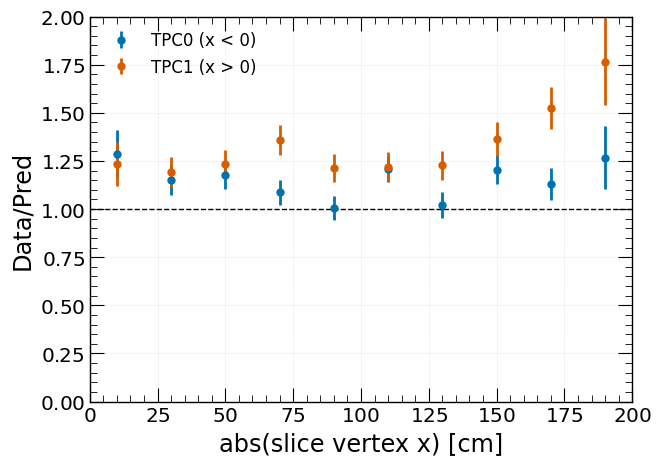

In [308]:
# Plot data/mc ratio of x vertex for tpc on same plot
cut = 'cut.all'
bins = np.arange(0, 220, 20)
bin_centers = (bins[:-1] + bins[1:]) / 2

_slc = slc_mc.copy()
_slc_data = slc_data.copy()
_slc.apply_cut(cut)
_slc_data.apply_cut(cut)

def tpc_vtx_ratio(slc_obj, slc_data_obj, tpc_mask_mc, tpc_mask_data):
    """Binned data/mc ratio and data stat error for one TPC."""
    vtx_x_mc = slc_obj.data.slc.vertex.x[tpc_mask_mc]
    w_mc = slc_obj.data.genweight[tpc_mask_mc]
    mc_counts, _ = np.histogram(np.abs(vtx_x_mc), bins=bins, weights=w_mc)

    vtx_x_data = slc_data_obj.data.slc.vertex.x[tpc_mask_data]
    data_counts, _ = np.histogram(np.abs(vtx_x_data), bins=bins)

    with np.errstate(divide='ignore', invalid='ignore'):
        ratio = data_counts / mc_counts
        ratio_err = np.sqrt(data_counts) / mc_counts
    valid = (mc_counts > 0) & np.isfinite(ratio)
    return ratio[valid], ratio_err[valid], bin_centers[valid]

vtx_x_mc = _slc.data.slc.vertex.x
vtx_x_data = _slc_data.data.slc.vertex.x
tpc_specs = [
    ('TPC0 (x < 0)', vtx_x_mc < 0, vtx_x_data < 0, 'C0'),
    ('TPC1 (x > 0)', vtx_x_mc > 0, vtx_x_data > 0, 'C1'),
]

fig, ax = plt.subplots(figsize=(7, 5))
for label, mc_mask, data_mask, color in tpc_specs:
    ratio, ratio_err, centers = tpc_vtx_ratio(_slc, _slc_data, mc_mask, data_mask)
    ax.errorbar(
        centers, ratio, yerr=ratio_err,
        fmt='o', label=label, color=color, markersize=5,
    )

ax.axhline(1, ls='--', color='k', linewidth=1)
ax.set_xlabel(r'abs(slice vertex x) [cm]')
ax.set_ylabel('Data/Pred')
ax.set_xlim(bins[0], bins[-1])
ax.set_ylim(0, 2)
ax.legend()
ax.grid(True, alpha=0.3)
plot_dir = f'{PLOT_DIR}/tpc_comparison'
plotters.save_plot(f'vtx_x_ratio_{cut.replace(".", "_")}', fig, folder_name=plot_dir)
plt.show()

## 6. Plots comparing reprocessing

In [9]:
_slc_mc = slc_mc.copy()
_slc_data = slc_data.copy()
_slc_mc_datadriven = slc_mc_datadriven.copy()
_slc_data_rep = slc_data_rep.copy()

_pfp_mc = pfp_mc.copy()
_pfp_data = pfp_data.copy()
_pfp_mc_datadriven = pfp_mc_datadriven.copy()
_pfp_data_rep = pfp_data_rep.copy()

### 6.1 Get objects with cuts applied

In [26]:
_slc_mc.apply_cut('cut.all',cut=True)
_slc_mc_datadriven.apply_cut('cut.all',cut=True)

_slc_data.apply_cut('cut.all',cut=True)
_slc_data_rep.apply_cut('cut.all',cut=True)

print(f'Before len(_pfp_mc.data): {len(_pfp_mc.data)}')
print(f'Before len(_pfp_data.data): {len(_pfp_data.data)}')
print(f'Before len(_pfp_mc_datadriven.data): {len(_pfp_mc_datadriven.data)}')
print(f'Before len(_pfp_data_rep.data): {len(_pfp_data_rep.data)}')
_pfp_mc.data = _slc_mc.get_reference_df(_pfp_mc)
_pfp_mc_datadriven.data = _slc_mc_datadriven.get_reference_df(_pfp_mc_datadriven)

_pfp_data.data = _slc_data.get_reference_df(_pfp_data)
_pfp_data_rep.data = _slc_data_rep.get_reference_df(_pfp_data_rep)
print(f'After len(_pfp_mc.data): {len(_pfp_mc.data)}')
print(f'After len(_pfp_data.data): {len(_pfp_data.data)}')
print(f'After len(_pfp_mc_datadriven.data): {len(_pfp_mc_datadriven.data)}')
print(f'After len(_pfp_data_rep.data): {len(_pfp_data_rep.data)}')

Applied cut on key: cut.all (44,615 --> 44,615)
Applied cut on key: cut.all (7,481 --> 7,481)
Applied cut on key: cut.all (4,394 --> 4,394)
Applied cut on key: cut.all (4,667 --> 4,667)
Before len(_pfp_mc.data): 102594
Before len(_pfp_data.data): 9217
Before len(_pfp_mc_datadriven.data): 17198
Before len(_pfp_data_rep.data): 9646
After len(_pfp_mc.data): 102594
After len(_pfp_data.data): 9217
After len(_pfp_mc_datadriven.data): 17198
After len(_pfp_data_rep.data): 9646


In [27]:
_slc_mc.data.cut.cont_full.value_counts()

cont_full
True    44615
Name: count, dtype: int64

In [28]:
slc_mc.data.genweight.sum()

20765.320937340926

### 6.2 Extract variables

In [21]:
from sbnd.numu.numu_constants import *

In [29]:
# Get MC variables
costheta_mc = _slc_mc.data.mu.pfp.trk.costheta
momentum_mc = _slc_mc.data.mu.pfp.trk.P.p_muon
length_mc = _slc_mc.data.mu.pfp.trk.len

start_x_mc = _slc_mc.data.mu.pfp.trk.start.x
start_y_mc = _slc_mc.data.mu.pfp.trk.start.y
start_z_mc = _slc_mc.data.mu.pfp.trk.start.z

end_x_mc = _slc_mc.data.mu.pfp.trk.end.x
end_y_mc = _slc_mc.data.mu.pfp.trk.end.y
end_z_mc = _slc_mc.data.mu.pfp.trk.end.z

phi_mc = _slc_mc.data.mu.pfp.trk.phi

direction_x_mc = _slc_mc.data.mu.pfp.trk.dir.x
direction_y_mc = _slc_mc.data.mu.pfp.trk.dir.y
direction_z_mc = _slc_mc.data.mu.pfp.trk.dir.z

interaction_x_mc = _slc_mc.data.slc.vertex.x
interaction_y_mc = _slc_mc.data.slc.vertex.y
interaction_z_mc = _slc_mc.data.slc.vertex.z

weights_mc = _slc_mc.data.genweight

# Get MC datadriven variables
costheta_mc_datadriven = _slc_mc_datadriven.data.mu.pfp.trk.costheta
momentum_mc_datadriven = _slc_mc_datadriven.data.mu.pfp.trk.P.p_muon
length_mc_datadriven = _slc_mc_datadriven.data.mu.pfp.trk.len

start_x_mc_datadriven = _slc_mc_datadriven.data.mu.pfp.trk.start.x
start_y_mc_datadriven = _slc_mc_datadriven.data.mu.pfp.trk.start.y
start_z_mc_datadriven = _slc_mc_datadriven.data.mu.pfp.trk.start.z

end_x_mc_datadriven = _slc_mc_datadriven.data.mu.pfp.trk.end.x
end_y_mc_datadriven = _slc_mc_datadriven.data.mu.pfp.trk.end.y
end_z_mc_datadriven = _slc_mc_datadriven.data.mu.pfp.trk.end.z

phi_mc_datadriven = _slc_mc_datadriven.data.mu.pfp.trk.phi

direction_x_mc_datadriven = _slc_mc_datadriven.data.mu.pfp.trk.dir.x
direction_y_mc_datadriven = _slc_mc_datadriven.data.mu.pfp.trk.dir.y
direction_z_mc_datadriven = _slc_mc_datadriven.data.mu.pfp.trk.dir.z

interaction_x_mc_datadriven = _slc_mc_datadriven.data.slc.vertex.x
interaction_y_mc_datadriven = _slc_mc_datadriven.data.slc.vertex.y
interaction_z_mc_datadriven = _slc_mc_datadriven.data.slc.vertex.z

weights_mc_datadriven = _slc_mc_datadriven.data.genweight

# Get data variables
costheta_data = _slc_data.data.mu.pfp.trk.costheta
momentum_data = _slc_data.data.mu.pfp.trk.P.p_muon
length_data = _slc_data.data.mu.pfp.trk.len

start_x_data = _slc_data.data.mu.pfp.trk.start.x
start_y_data = _slc_data.data.mu.pfp.trk.start.y
start_z_data = _slc_data.data.mu.pfp.trk.start.z

end_x_data = _slc_data.data.mu.pfp.trk.end.x
end_y_data = _slc_data.data.mu.pfp.trk.end.y
end_z_data = _slc_data.data.mu.pfp.trk.end.z

phi_data = _slc_data.data.mu.pfp.trk.phi

direction_x_data = _slc_data.data.mu.pfp.trk.dir.x
direction_y_data = _slc_data.data.mu.pfp.trk.dir.y
direction_z_data = _slc_data.data.mu.pfp.trk.dir.z

interaction_x_data = _slc_data.data.slc.vertex.x
interaction_y_data = _slc_data.data.slc.vertex.y
interaction_z_data = _slc_data.data.slc.vertex.z

weights_data = _slc_data.data.genweight

# Get reprocessed variables
costheta_data_rep = _slc_data_rep.data.mu.pfp.trk.costheta
momentum_data_rep = _slc_data_rep.data.mu.pfp.trk.P.p_muon
length_data_rep = _slc_data_rep.data.mu.pfp.trk.len

start_x_data_rep = _slc_data_rep.data.mu.pfp.trk.start.x
start_y_data_rep = _slc_data_rep.data.mu.pfp.trk.start.y
start_z_data_rep = _slc_data_rep.data.mu.pfp.trk.start.z

end_x_data_rep = _slc_data_rep.data.mu.pfp.trk.end.x
end_y_data_rep = _slc_data_rep.data.mu.pfp.trk.end.y
end_z_data_rep = _slc_data_rep.data.mu.pfp.trk.end.z

phi_data_rep = _slc_data_rep.data.mu.pfp.trk.phi

direction_x_data_rep = _slc_data_rep.data.mu.pfp.trk.dir.x
direction_y_data_rep = _slc_data_rep.data.mu.pfp.trk.dir.y
direction_z_data_rep = _slc_data_rep.data.mu.pfp.trk.dir.z

interaction_x_data_rep = _slc_data_rep.data.slc.vertex.x
interaction_y_data_rep = _slc_data_rep.data.slc.vertex.y
interaction_z_data_rep = _slc_data_rep.data.slc.vertex.z

weights_data_rep = _slc_data_rep.data.genweight

In [30]:
weights_mc.sum()

3634.0289077237635

In [31]:
from sbnd.general.utils import format_number_with_suffix
# Dictionary of labels, names, and plot kwargs 
proc_dict = {
  'mc': {
    'label': 'MC CV',
    'color': 'C0',
    'weights': weights_mc.values,
    'style': 'line',
    'total': format_number_with_suffix(weights_mc.sum()),
  },
  'datadriven': {
    'label': 'MC DataDrivenV4',
    'color': 'C1',
    'weights': weights_mc_datadriven.values,
    'style': 'line',
    'total': format_number_with_suffix(weights_mc_datadriven.sum()),
  },
  'data': {
    'label': 'Data',
    'color': 'black',
    'weights': weights_data.values,
    'style': 'scatter',
    'total': format_number_with_suffix(weights_data.sum()),
  },
  'datarep': {
    'label': 'Data Reprocessed',
    'color': 'red',
    'weights': weights_data_rep.values,
    'style': 'scatter',
    'total': format_number_with_suffix(weights_data_rep.sum()),
  }
}

# Per-TPC masks from interaction_x; totals recomputed after mask.
_proc_vtx_x = {
  'mc': np.asarray(interaction_x_mc),
  'datadriven': np.asarray(interaction_x_mc_datadriven),
  'data': np.asarray(interaction_x_data),
  'datarep': np.asarray(interaction_x_data_rep),
}
for proc, proc_info in proc_dict.items():
  x = _proc_vtx_x[proc]
  w = proc_info['weights']
  mask_tpc0 = x <= 0  # x==0 shoved into TPC0
  mask_tpc1 = x > 0
  proc_info['masks'] = {'combined': None, 'TPC0': mask_tpc0, 'TPC1': mask_tpc1}
  proc_info['totals'] = {
    'combined': proc_info['total'],
    'TPC0': format_number_with_suffix(np.asarray(w)[mask_tpc0].sum()),
    'TPC1': format_number_with_suffix(np.asarray(w)[mask_tpc1].sum()),
  }

tpc_plot_specs = [
  ('combined', 'All Cuts'),
  ('TPC0', 'All Cuts - TPC 0 (x < 0)'),
  ('TPC1', 'All Cuts - TPC 1 (x > 0)'),
]

# Dictionary of variables, binnings, labels. 
var_dict = {
  'costheta': {
    'label': r'$\cos\theta_\mu$',
    'bins': np.arange(-1,1.1,0.1),
    'mc': costheta_mc,
    'datadriven': costheta_mc_datadriven,
    'data': costheta_data,
    'datarep': costheta_data_rep,
  },
  'momentum': {
    'label': r'$p_\mu$ [GeV]',
    'bins': np.arange(0,2.1,0.1),
    'mc': momentum_mc,
    'datadriven': momentum_mc_datadriven,
    'data': momentum_data,
    'datarep': momentum_data_rep,
  },
  'length': {
    'label': r'$\ell_\mu$ [cm]',
    'bins': TRACK_LENGTH_BINS,
    'mc': length_mc,
    'datadriven': length_mc_datadriven,
    'data': length_data,
    'datarep': length_data_rep,
  },
  'start_x': {
    'label': r'Muon Start $x$ [cm]',
    'bins': TRACK_XY_BINS,
    'mc': start_x_mc,
    'datadriven': start_x_mc_datadriven,
    'data': start_x_data,
    'datarep': start_x_data_rep,
  },
  'start_y': {
    'label': r'Muon Start $y$ [cm]',
    'bins': TRACK_XY_BINS,
    'mc': start_y_mc,
    'datadriven': start_y_mc_datadriven,
    'data': start_y_data,
    'datarep': start_y_data_rep,
  },
  'start_z': {
    'label': r'Muon Start $z$ [cm]',
    'bins': TRACK_Z_BINS,
    'mc': start_z_mc,
    'datadriven': start_z_mc_datadriven,
    'data': start_z_data,
    'datarep': start_z_data_rep,
  },
  'end_x': {
    'label': r'Muon End $x$ [cm]',
    'bins': TRACK_XY_BINS,
    'mc': end_x_mc,
    'datadriven': end_x_mc_datadriven,
    'data': end_x_data,
    'datarep': end_x_data_rep,
  },
  'end_y': {
    'label': r'Muon End $y$ [cm]',
    'bins': TRACK_XY_BINS,
    'mc': end_y_mc,
    'datadriven': end_y_mc_datadriven,
    'data': end_y_data,
    'datarep': end_y_data_rep,
  },
  'end_z': {
    'label': r'Muon End $z$ [cm]',
    'bins': TRACK_Z_BINS,
    'mc': end_z_mc,
    'datadriven': end_z_mc_datadriven,
    'data': end_z_data,
    'datarep': end_z_data_rep,
  },
  'phi': {
    'label': r'$\phi_\mu$ [rad]',
    'bins': TRACK_PHI_BINS,
    'mc': phi_mc,
    'datadriven': phi_mc_datadriven,
    'data': phi_data,
    'datarep': phi_data_rep,
    'bins': TRACK_PHI_BINS,
    'mc': phi_mc,
    'datadriven': phi_mc_datadriven,
    'data': phi_data,
    'datarep': phi_data_rep,
  },
  'direction_x': {
    'label': r'Muon Direction $x$',
    'bins': np.arange(-1,1.1,0.1),
    'mc': direction_x_mc,
    'datadriven': direction_x_mc_datadriven,
    'data': direction_x_data,
    'datarep': direction_x_data_rep,
  },
  'direction_y': {
    'label': r'Muon Direction $y$',
    'bins': np.arange(-1,1.1,0.1),
    'mc': direction_y_mc,
    'datadriven': direction_y_mc_datadriven,
    'data': direction_y_data,
    'datarep': direction_y_data_rep,
  },
  'interaction_x': {
    'label': r'Vertex $x$ [cm]',
    'bins': TRACK_XY_BINS,
    'mc': interaction_x_mc,
    'datadriven': interaction_x_mc_datadriven,
    'data': interaction_x_data,
    'datarep': interaction_x_data_rep,
  },
  'interaction_y': {
    'label': r'Vertex $y$ [cm]',
    'bins': TRACK_XY_BINS,
    'mc': interaction_y_mc,
    'datadriven': interaction_y_mc_datadriven,
    'data': interaction_y_data,
    'datarep': interaction_y_data_rep,
  },
  'interaction_z': {
    'label': r'Vertex $z$ [cm]',
    'bins': TRACK_Z_BINS,
    'mc': interaction_z_mc,
    'datadriven': interaction_z_mc_datadriven,
    'data': interaction_z_data,
    'datarep': interaction_z_data_rep,
  }
}


### 6.3 Make plots

In [38]:
from sbnd.plotlibrary import makeplot
from naming import *

def apply_tpc_mask(values, weights, mask):
  """Return values/weights unchanged if mask is None, else index both."""
  values = np.asarray(values)
  weights = np.asarray(weights)
  if mask is None:
    return values, weights
  return values[mask], weights[mask]


def plot_var_hist(var_info, proc_dict, tpc_tag, title, folder, fname_stem):
  """One absolute hist for all procs, optionally TPC-masked via proc masks[tpc_tag]."""
  bins = var_info['bins']
  bin_centers = (bins[:-1] + bins[1:]) / 2
  fig, ax = plt.subplots()
  for proc, proc_info in proc_dict.items():
    mask = proc_info['masks'][tpc_tag]
    values, weights = apply_tpc_mask(var_info[proc], proc_info['weights'], mask)
    counts, _ = np.histogram(values, bins=bins, weights=weights)
    label = f'{proc_info["label"]} ({proc_info["totals"][tpc_tag]})'
    if proc_info['style'] == 'line':
      makeplot.plot_hist_edges(bins, counts, label=label, color=proc_info['color'], ax=ax)
    elif proc_info['style'] == 'scatter':
      ax.errorbar(bin_centers, counts, yerr=np.sqrt(counts), label=label,
                  color=proc_info['color'], fmt='o')
  ax.legend()
  ax.set_ylim(0,ax.get_ylim()[1]*1.2)
  ax.set_xlabel(var_info['label'])
  ax.set_ylabel('Candidates')
  ax.set_title(title)
  plotters.add_label(ax, POT_LABEL, where=(1.0, 1.07),
    color='black', alpha=1., fontsize=12, horizontalalignment='right', verticalalignment='top')
  plotters.add_label(ax, INTERNAL_DATA_LABEL, where=(0.01, 1.07),
    color='black', alpha=1., fontsize=12, horizontalalignment='left', verticalalignment='top')
  plotters.save_plot(f'{fname_stem}_contcut', fig, folder_name=folder)
  plt.close(fig)


#### 6.3.1 Standard Hists

In [39]:
tpc_plot_specs

[('combined', 'All Cuts'),
 ('TPC0', 'All Cuts - TPC 0 (x < 0)'),
 ('TPC1', 'All Cuts - TPC 1 (x > 0)')]

In [40]:
# plot_vars = None plots all var_dict keys; set a list to downsample.
plot_vars = None
vars_to_plot = list(var_dict) if plot_vars is None else plot_vars

base = f'{PLOT_DIR}/dent_studies/var_comparison'
for tpc_tag, title in tpc_plot_specs:
  folder = f'{base}/{tpc_tag}'
  for var in tqdm(vars_to_plot, desc=f'{tpc_tag} hists'):
    plot_var_hist(
      var_dict[var], proc_dict,
      tpc_tag=tpc_tag,
      title=title,
      folder=folder,
      fname_stem=f'{var}_{tpc_tag}',
    )


combined hists:   0%|          | 0/15 [00:00<?, ?it/s]

TPC1 hists: 100%|██████████| 15/15 [00:07<00:00,  2.12it/s]


#### 6.3.2 Ratio hists (like 5.1)

In [42]:
# Per-TPC Data/Pred ratios for position vars. Loop data + datarep into separate folders.
data_keys = ['data', 'datarep']
pred_keys = ['mc', 'datadriven']
ABS_X_BINS = np.arange(0, 220, 20)
tpc_vars = [
  'interaction_x', 'interaction_y', 'interaction_z',
  'start_x', 'start_y', 'start_z',
  'end_x', 'end_y', 'end_z',
]
tpc_specs = [
  ('TPC0', lambda x: x < 0, 'o'),
  ('TPC1', lambda x: x > 0, 's'),
]
# Unique shade per TPC within each pred family
series_color = {
  ('TPC0', 'mc'): '#1f77b4',       # CV dark blue
  ('TPC1', 'mc'): '#9ecae1',       # CV light blue
  ('TPC0', 'datadriven'): '#ff7f0e',  # DD dark orange
  ('TPC1', 'datadriven'): '#ffbb78',  # DD light orange
}
vtx_x = {k: np.asarray(var_dict['interaction_x'][k]) for k in pred_keys + data_keys}

def tpc_ratio(var_vals, weights, data_vals, data_weights, bins, mask_pred, mask_data, use_abs):
  """Binned Data/Pred ratio and data-stat error for one TPC (full bin arrays)."""
  x_pred = np.abs(var_vals[mask_pred]) if use_abs else var_vals[mask_pred]
  x_data = np.abs(data_vals[mask_data]) if use_abs else data_vals[mask_data]
  pred_counts, _ = np.histogram(x_pred, bins=bins, weights=weights[mask_pred])
  data_counts, _ = np.histogram(x_data, bins=bins, weights=data_weights[mask_data])
  centers = (bins[:-1] + bins[1:]) / 2
  with np.errstate(divide='ignore', invalid='ignore'):
    ratio = data_counts / pred_counts
    ratio_err = np.sqrt(data_counts) / pred_counts
  return ratio, ratio_err, centers, pred_counts


def tpc_ratio_delta_chi2(ratio0, err0, pred0, ratio1, err1, pred1):
  """chi2 for Delta = R0 - R1; denom from data-stat errs sqrt(N)/P -> N/P^2 per TPC."""
  shared = (
    (pred0 > 0) & (pred1 > 0)
    & np.isfinite(ratio0) & np.isfinite(ratio1)
    & np.isfinite(err0) & np.isfinite(err1)
    & (err0 > 0) & (err1 > 0)
  )
  if not np.any(shared):
    return np.nan, 0
  delta = ratio0[shared] - ratio1[shared]
  sigma_delta = np.sqrt(err0[shared]**2 + err1[shared]**2)
  chi2 = float(np.sum((delta / sigma_delta)**2))
  return chi2, int(shared.sum())

for data_key in data_keys:
  folder = f'{PLOT_DIR}/dent_studies/tpc_ratio/{data_key}'
  data_label = proc_dict[data_key]['label']
  for var in tqdm(tpc_vars, desc=f'TPC ratio vs {data_key}'):
    var_info = var_dict[var]
    use_abs = var.endswith('_x')
    bins = ABS_X_BINS if use_abs else var_info['bins']
    fig, ax = plt.subplots(figsize=(7, 5))
    delta_lines = []
    for pred in pred_keys:
      ratios_by_tpc = {}
      for tpc_name, mask_fn, marker in tpc_specs:
        ratio, ratio_err, centers, pred_counts = tpc_ratio(
          np.asarray(var_info[pred]), proc_dict[pred]['weights'],
          np.asarray(var_info[data_key]), proc_dict[data_key]['weights'],
          bins,
          mask_fn(vtx_x[pred]), mask_fn(vtx_x[data_key]),
          use_abs,
        )
        ratios_by_tpc[tpc_name] = (ratio, ratio_err, pred_counts)
        valid = (pred_counts > 0) & np.isfinite(ratio)
        ax.errorbar(
          centers[valid], ratio[valid], yerr=ratio_err[valid],
          fmt=marker, color=series_color[(tpc_name, pred)], markersize=5,
          label=f'{tpc_name} {proc_dict[pred]["label"]}',
        )
      r0, e0, p0 = ratios_by_tpc['TPC0']
      r1, e1, p1 = ratios_by_tpc['TPC1']
      chi2, ndf = tpc_ratio_delta_chi2(r0, e0, p0, r1, e1, p1)
      if ndf > 0:
        delta_lines.append(rf'{proc_dict[pred]["label"]}: $\chi^2$/ndf = {chi2:.1f}/{ndf}')
      else:
        delta_lines.append(rf'{proc_dict[pred]["label"]}: $\chi^2$/ndf = n/a')
    ax.axhline(1, ls='--', color='k', linewidth=1)
    ax.set_xlabel(rf'abs({var_info["label"]})' if use_abs else var_info['label'])
    ax.set_ylabel('Data/Pred')
    ax.set_xlim(bins[0], bins[-1])
    ax.set_ylim(0, 2)
    ax.set_title(f'Per-TPC ratio vs {data_label}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    # Delta = R0 - R1; sigma_Delta^2 = N0/P0^2 + N1/P1^2 (N=data, P=pred); chi2 = sum((Delta/sigma_Delta)^2)
    box_text = (
      r'$\Delta = R_0 - R_1,\ \sigma_\Delta = \sqrt{N_0/P_0^2 + N_1/P_1^2}$'
      + '\n'
      + r'($N$=data, $P$=pred)'
      + '\n'
      + r'$\chi^2 = \sum_i (\Delta_i / \sigma_{\Delta,i})^2$'
      + '\n' + '\n'.join(delta_lines)
    )
    ax.text(
      0.02, 0.02, box_text, transform=ax.transAxes,
      fontsize=9, verticalalignment='bottom', horizontalalignment='left',
      bbox=dict(boxstyle='round', facecolor='white', alpha=0.85, edgecolor='gray'),
    )
    plotters.add_label(ax, POT_LABEL, where=(1.0, 1.07),
      color='black', alpha=1., fontsize=12, horizontalalignment='right', verticalalignment='top')
    plotters.add_label(ax, INTERNAL_LABEL, where=(0.01, 1.07),
      color='black', alpha=1., fontsize=12, horizontalalignment='left', verticalalignment='top')
    plotters.save_plot(f'{var}_ratio_{data_key}', fig, folder_name=folder)
    plt.close(fig)
  #   break
  # break


TPC ratio vs data:   0%|          | 0/9 [00:00<?, ?it/s]

TPC ratio vs datarep: 100%|██████████| 9/9 [00:05<00:00,  1.52it/s]


## Testing

In [168]:
fname = '/exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/mc_syst/v9/mcbnb_tinypand_slimsyst_nocuts_recomb.df'
_slc = CAFSlice.load(fname,key=PAND_KEY,ncpu=NCPU,show_progress=True,verbose=True)
_pfp = PFP.load(fname,key=PFP_KEY,ncpu=NCPU,show_progress=True,verbose=True)
np.unique(_slc.data.cut.all_cont,return_counts=True)

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = '/exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/mc_syst/v9/mcbnb_tinypand_slimsyst_nocuts_recomb.df', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [44]:
#Apply cut to slc
_slc.apply_cut('cut.all_cont',cut=True)

# Get reference pfp
_pfp.data = _slc.get_reference_df(_pfp)

slc_keys = ['run','subrun','evt','cut.all_cont','cut.cont']
slc_cols = _slc.get_key(slc_keys)
pfp_keys = ['pfp.trk.cont_tpc0','pfp.trk.cont_tpc1']
pfp_cols = _pfp.get_key(pfp_keys)

Applied cut on key: cut.all_cont (3,016 --> 144)


In [45]:
_pfp.data.loc[:,pfp_cols]

pfp          
                                                            trk          
                                                      cont_tpc0 cont_tpc1
                                                                         
                                                                         
                                                                         
__ntuple entry rec.slc..index rec.slc.reco.pfp..index                    
0        2     0              0                           False      True
         3     0              0                           False      True
                              1                           False      True
                              2                           False      True
               1              0                            True     False
..                                                          ...       ...
1        158   0              0                           False      True
                              1                           False      True
                              2                           False      True
         160   1              0                           False      True
                              1                           False      True

[236 rows x 2 columns]

In [46]:
with open('/exp/sbnd/app/users/brindenc/develop/cafpyana/analysis_village/numuincl/logs/slc_slim_keys.txt','w') as f:
  for key in _slc.data.truth.keys():
    f.write(f'{key}\n')
